In [1]:
from web3 import Web3

# Connect to local Ganache blockchain
ganache_url = "http://127.0.0.1:7545"  # Change port if needed
web3 = Web3(Web3.HTTPProvider(ganache_url))

# Check connection
if web3.is_connected():
    print("✅ Connected to Ganache successfully!")
else:
    print("❌ Connection failed. Ensure Ganache is running.")

✅ Connected to Ganache successfully!


In [2]:
# Replace with your actual contract address
contract_address = "0x473265c5f420d1AA5F9686F9A31aF0f3B1190EEE"

# abi here please!!
abi = [
    
	{
		"inputs": [],
		"stateMutability": "nonpayable",
		"type": "constructor"
	},
	{
		"anonymous": False,
		"inputs": [
			{
				"indexed": False,
				"internalType": "string",
				"name": "packageId",
				"type": "string"
			},
			{
				"indexed": False,
				"internalType": "uint256",
				"name": "timestamp",
				"type": "uint256"
			},
			{
				"indexed": False,
				"internalType": "string",
				"name": "city",
				"type": "string"
			},
			{
				"indexed": False,
				"internalType": "int256",
				"name": "latitude",
				"type": "int256"
			},
			{
				"indexed": False,
				"internalType": "int256",
				"name": "longitude",
				"type": "int256"
			},
			{
				"indexed": False,
				"internalType": "int256",
				"name": "temperatureCelsius",
				"type": "int256"
			},
			{
				"indexed": False,
				"internalType": "string",
				"name": "status",
				"type": "string"
			}
		],
		"name": "PackageUpdated",
		"type": "event"
	},
	{
		"inputs": [
			{
				"internalType": "string",
				"name": "packageId",
				"type": "string"
			},
			{
				"internalType": "string",
				"name": "city",
				"type": "string"
			},
			{
				"internalType": "int256",
				"name": "latitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "longitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "temperatureCelsius",
				"type": "int256"
			},
			{
				"internalType": "string",
				"name": "status",
				"type": "string"
			}
		],
		"name": "storeUpdate",
		"outputs": [],
		"stateMutability": "nonpayable",
		"type": "function"
	},
	{
		"inputs": [],
		"name": "getAllPackageIds",
		"outputs": [
			{
				"internalType": "string[]",
				"name": "",
				"type": "string[]"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "string",
				"name": "packageId",
				"type": "string"
			}
		],
		"name": "getLatestUpdate",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "timestamp",
				"type": "uint256"
			},
			{
				"internalType": "string",
				"name": "city",
				"type": "string"
			},
			{
				"internalType": "int256",
				"name": "latitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "longitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "temperatureCelsius",
				"type": "int256"
			},
			{
				"internalType": "string",
				"name": "status",
				"type": "string"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "string",
				"name": "packageId",
				"type": "string"
			},
			{
				"internalType": "uint256",
				"name": "index",
				"type": "uint256"
			}
		],
		"name": "getUpdateByIndex",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "timestamp",
				"type": "uint256"
			},
			{
				"internalType": "string",
				"name": "city",
				"type": "string"
			},
			{
				"internalType": "int256",
				"name": "latitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "longitude",
				"type": "int256"
			},
			{
				"internalType": "int256",
				"name": "temperatureCelsius",
				"type": "int256"
			},
			{
				"internalType": "string",
				"name": "status",
				"type": "string"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [
			{
				"internalType": "string",
				"name": "packageId",
				"type": "string"
			}
		],
		"name": "getUpdateCount",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [],
		"name": "MAX_ENTRIES",
		"outputs": [
			{
				"internalType": "uint256",
				"name": "",
				"type": "uint256"
			}
		],
		"stateMutability": "view",
		"type": "function"
	},
	{
		"inputs": [],
		"name": "owner",
		"outputs": [
			{
				"internalType": "address",
				"name": "",
				"type": "address"
			}
		],
		"stateMutability": "view",
		"type": "function"
	}

]

# Load the smart contract
contract = web3.eth.contract(address=contract_address, abi=abi)

# Set the default sender address (first account from Ganache)
web3.eth.default_account = web3.eth.accounts[0]

print(f"✅ Connected to Smart Contract at {contract_address}")

✅ Connected to Smart Contract at 0x473265c5f420d1AA5F9686F9A31aF0f3B1190EEE


In [3]:
#sample logistics update
txn = contract.functions.storeUpdate(
    "TESTPKG001",      # packageId
    "Pasig",           # city
    145764000,         # latitude (14.5764000 * 1e7)
    1210851000,        # longitude (121.0851000 * 1e7)
    250,               # temperatureCelsius (25.0°C * 10)
    "in transit"       # status
).transact({
    'from': web3.eth.default_account,
    'gas': 1000000
})
web3.eth.wait_for_transaction_receipt(txn)
print("✅ Sample data stored on blockchain!")

✅ Sample data stored on blockchain!


In [5]:
# Store a dummy logistics update
txn = contract.functions.storeUpdate(
    "TESTPKG001",      # packageId
    "Pasig",           # city
    145764000,         # latitude (14.5764000 * 1e7)
    1210851000,        # longitude (121.0851000 * 1e7)
    250,               # temperatureCelsius (25.0°C * 10)
    "in transit"       # status
).transact({
    'from': web3.eth.default_account,
    'gas': 1000000
})
web3.eth.wait_for_transaction_receipt(txn)
print("✅ Dummy data stored on blockchain!")

✅ Dummy data stored on blockchain!


In [6]:
# Retrieve the latest update for the test package
latest_update = contract.functions.getLatestUpdate("TESTPKG001").call()
print("Latest update for TESTPKG001:")
print("Timestamp:", latest_update[0])
print("City:", latest_update[1])
print("Latitude:", latest_update[2] / 1e7)
print("Longitude:", latest_update[3] / 1e7)
print("Temperature (°C):", latest_update[4] / 10)
print("Status:", latest_update[5])

Latest update for TESTPKG001:
Timestamp: 1749392182
City: Pasig
Latitude: 14.5764
Longitude: 121.0851
Temperature (°C): 25.0
Status: in transit


In [7]:
count = contract.functions.getUpdateCount("TESTPKG001").call()
print("Total Records Before Storing Data:", count)

Total Records Before Storing Data: 2


In [8]:
import pandas as pd

# Load your IoT data CSV
df = pd.read_csv("iot_data.csv")

# Number of records in CSV file
num_records = len(df)
print("Number of records in CSV file:", num_records)

# First three records in CSV
print("First three records in CSV:")
print(df.head(3))

Number of records in CSV file: 100
First three records in CSV:
                    timestamp package_id      city  latitude  longitude  \
0  2025-05-27 07:12:06.833283    PKG9346  Caloocan   14.6561   120.9830   
1  2025-05-27 08:58:06.834998    PKG4537     Pasig   14.5764   121.0851   
2  2025-05-27 13:02:06.835083    PKG2640  Caloocan   14.6561   120.9830   

   temperature_celsius      status  
0                 24.9  in transit  
1                 28.6     delayed  
2                 28.7     delayed  


In [9]:
tx_hashes = []

for idx, row in df.iterrows():
    txn = contract.functions.storeUpdate(
        str(row['package_id']),
        str(row['city']),
        int(row['latitude'] * 1e7),      # Convert to int for Solidity
        int(row['longitude'] * 1e7),     # Convert to int for Solidity
        int(row['temperature_celsius'] * 10),  # Convert to int for Solidity
        str(row['status'])
    ).transact({
        'from': web3.eth.default_account,
        'gas': 1000000
    })
    tx_hashes.append(txn.hex())  # Store the transaction hash

print("Number of records successfully stored on blockchain:", len(tx_hashes))
print("Transaction Hash of first stored record:", tx_hashes[0])
print("Transaction Hash of last stored record:", tx_hashes[-1])

Number of records successfully stored on blockchain: 100
Transaction Hash of first stored record: 4d7b89c4590a6d41252dd9cd7346ffb31264b5504ed4f0285204f54834fa2d00
Transaction Hash of last stored record: ad133afda1aefb1a8b5bd57c14f6256e981b6bca3d967325ef84710d5382d7d3


In [10]:
# Get all package IDs
package_ids = contract.functions.getAllPackageIds().call()

# Total records now stored on blockchain (sum of all updates for all packages)
total_records = sum([contract.functions.getUpdateCount(pid).call() for pid in package_ids])
print("Total records now stored on blockchain:", total_records)

# Get the first package ID and its first record
first_package_id = package_ids[0]
first_record = contract.functions.getUpdateByIndex(first_package_id, 0).call()

print("First stored record retrieved from blockchain:")
print("Timestamp:", first_record[0])
print("Device ID (Package ID):", first_package_id)
print("City:", first_record[1])
print("Latitude:", first_record[2] / 1e7)
print("Longitude:", first_record[3] / 1e7)
print("Temperature (°C):", first_record[4] / 10)
print("Status:", first_record[5])

Total records now stored on blockchain: 102
First stored record retrieved from blockchain:
Timestamp: 1749391666
Device ID (Package ID): TESTPKG001
City: Pasig
Latitude: 14.5764
Longitude: 121.0851
Temperature (°C): 25.0
Status: in transit


In [11]:
import pandas as pd


# Load IoT sensor data from CSV (Generated in Homework 1)
df = pd.read_csv("iot_data.csv")


# Display the first few rows
print(df.head())




                    timestamp package_id              city  latitude  \
0  2025-05-27 07:12:06.833283    PKG9346          Caloocan   14.6561   
1  2025-05-27 08:58:06.834998    PKG4537             Pasig   14.5764   
2  2025-05-27 13:02:06.835083    PKG2640          Caloocan   14.6561   
3  2025-05-26 17:28:06.835105    PKG1173            Manila   14.5995   
4  2025-05-27 05:20:06.835125    PKG1784  San Jose Bulacan   15.1502   

   longitude  temperature_celsius      status  
0   120.9830                 24.9  in transit  
1   121.0851                 28.6     delayed  
2   120.9830                 28.7     delayed  
3   120.9842                 22.7     delayed  
4   120.9696                 28.8     delayed  


In [ ]:
from web3 import Web3


# Connect to local blockchain
ganache_url = "http://127.0.0.1:7545"
web3 = Web3(Web3.HTTPProvider(ganache_url))


# Verify connection
if web3.is_connected():
    print("✅ Connected to Ganache successfully!")
else:
    print("❌ Connection failed. Ensure Ganache is running.")


✅ Connected to Ganache successfully!


In [18]:
package_ids = contract.functions.getAllPackageIds().call()
total_records = len(package_ids)
print(f"Total IoT records stored: {total_records}")

Total IoT records stored: 101


In [19]:
import pandas as pd

# Step 1: Get all package IDs
package_ids = contract.functions.getAllPackageIds().call()

# Step 2: Retrieve all updates for each package
data = []
for package_id in package_ids:
    update_count = contract.functions.getUpdateCount(package_id).call()
    for index in range(update_count):
        update = contract.functions.getUpdateByIndex(package_id, index).call()
        data.append({
            "packageId": package_id,
            "timestamp": update[0],
            "city": update[1],
            "latitude": update[2],
            "longitude": update[3],
            "temperatureCelsius": update[4],
            "status": update[5]
        })

# Step 3: Create a DataFrame
df = pd.DataFrame(data)

# Step 4: Convert timestamp to readable format
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Step 5: Show the first few rows
print(df.head())

    packageId           timestamp      city   latitude   longitude  \
0  TESTPKG001 2025-06-08 14:07:46     Pasig  145764000  1210851000   
1  TESTPKG001 2025-06-08 14:16:22     Pasig  145764000  1210851000   
2     PKG9346 2025-06-08 14:18:45  Caloocan  146561000  1209830000   
3     PKG4537 2025-06-08 14:18:45     Pasig  145764000  1210851000   
4     PKG2640 2025-06-08 14:18:45  Caloocan  146561000  1209830000   

   temperatureCelsius      status  
0                 250  in transit  
1                 250  in transit  
2                 249  in transit  
3                 286     delayed  
4                 287     delayed  


In [20]:
import numpy as np

# Ensure 'temperatureCelsius' is numeric
df["temperatureCelsius"] = pd.to_numeric(df["temperatureCelsius"], errors="coerce")


# Handle missing values in all columns
df.fillna(0, inplace=True)

# Display cleaned data
print(df.head())

    packageId           timestamp      city   latitude   longitude  \
0  TESTPKG001 2025-06-08 14:07:46     Pasig  145764000  1210851000   
1  TESTPKG001 2025-06-08 14:16:22     Pasig  145764000  1210851000   
2     PKG9346 2025-06-08 14:18:45  Caloocan  146561000  1209830000   
3     PKG4537 2025-06-08 14:18:45     Pasig  145764000  1210851000   
4     PKG2640 2025-06-08 14:18:45  Caloocan  146561000  1209830000   

   temperatureCelsius      status  
0                 250  in transit  
1                 250  in transit  
2                 249  in transit  
3                 286     delayed  
4                 287     delayed  


In [21]:
# Save cleaned IoT data to a CSV file
df.to_csv("cleaned_iot_data.csv", index=False)

print("✅ Cleaned IoT data saved successfully as cleaned_iot_data.csv")


✅ Cleaned IoT data saved successfully as cleaned_iot_data.csv


In [1]:
import pandas as pd

# Load cleaned IoT data
df = pd.read_csv("cleaned_iot_data.csv")

# Display first few rows to verify data
print(df.head())

    packageId            timestamp      city   latitude   longitude  \
0  TESTPKG001  2025-06-08 14:07:46     Pasig  145764000  1210851000   
1  TESTPKG001  2025-06-08 14:16:22     Pasig  145764000  1210851000   
2     PKG9346  2025-06-08 14:18:45  Caloocan  146561000  1209830000   
3     PKG4537  2025-06-08 14:18:45     Pasig  145764000  1210851000   
4     PKG2640  2025-06-08 14:18:45  Caloocan  146561000  1209830000   

   temperatureCelsius      status  
0                 250  in transit  
1                 250  in transit  
2                 249  in transit  
3                 286     delayed  
4                 287     delayed  


In [2]:
# Reshape data to long format for plotting
df_long = df.melt(
    id_vars=["timestamp", "packageId", "city", "latitude", "longitude", "status"],
    value_vars=["temperatureCelsius"],
    var_name="data_type",
    value_name="numeric_value"
)
print(df_long.head())

             timestamp   packageId      city   latitude   longitude  \
0  2025-06-08 14:07:46  TESTPKG001     Pasig  145764000  1210851000   
1  2025-06-08 14:16:22  TESTPKG001     Pasig  145764000  1210851000   
2  2025-06-08 14:18:45     PKG9346  Caloocan  146561000  1209830000   
3  2025-06-08 14:18:45     PKG4537     Pasig  145764000  1210851000   
4  2025-06-08 14:18:45     PKG2640  Caloocan  146561000  1209830000   

       status           data_type  numeric_value  
0  in transit  temperatureCelsius            250  
1  in transit  temperatureCelsius            250  
2  in transit  temperatureCelsius            249  
3     delayed  temperatureCelsius            286  
4     delayed  temperatureCelsius            287  


In [4]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.6 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 11.4 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------------------------- -- 2.1/2.2 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 10.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


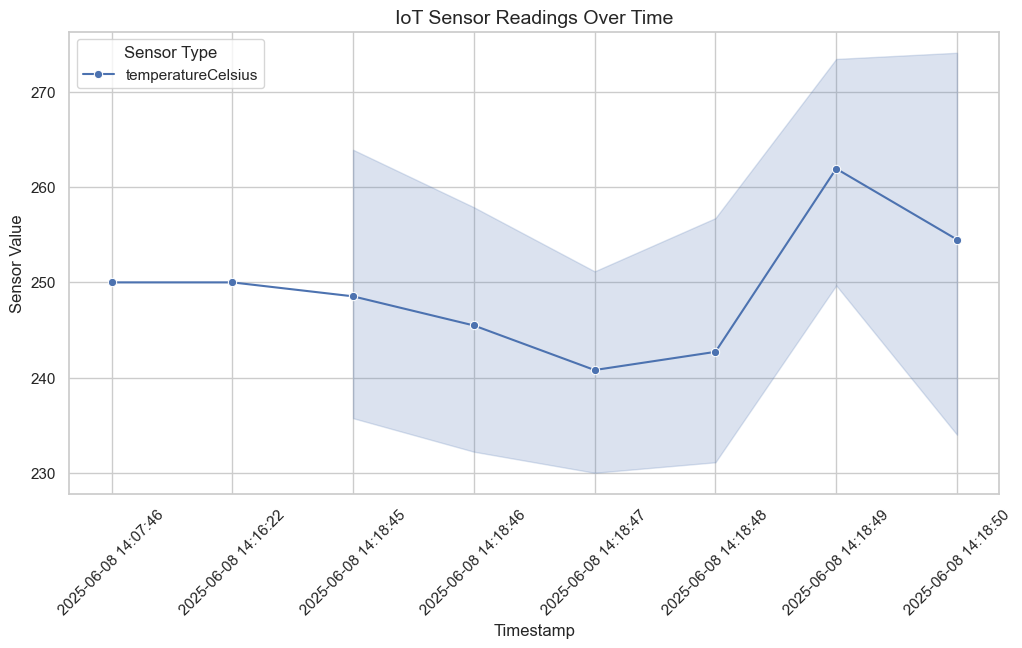

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set(style="whitegrid")

# Create the line plot
plt.figure(figsize=(12, 6))  
sns.lineplot(
    x=df_long["timestamp"],
    y=df_long["numeric_value"],
    hue=df_long["data_type"],
    marker="o"
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title("IoT Sensor Readings Over Time", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Sensor Value", fontsize=12)

# Show legend
plt.legend(title="Sensor Type")

# Display the plot
plt.show()